In [1]:
import numpy as np
import pandas as pd
import math

In [24]:
# import synthetic landscape to test

data_folder = 'nosfield/'

lscape_name_notxt = 'dipplane45_45_posdip_fee30_ini_7_13_17_A_1strong_erate'

img_folder = 'imgs/' + lscape_name_notxt + '/'

synscape = pd.read_csv(data_folder + lscape_name_notxt + '.txt', sep=' ')
print(synscape.shape)
print(synscape.columns)

(9604, 14)
Index(['x', 'y', 'z', 'ERate', 'TensileFailure', 'FailureType',
       'AmountRemoved', 'cohesion', 'friction', 'tension', 'strength_stress',
       'diff_stress', 'model', 'group'],
      dtype='object')


In [5]:
# clean up grid

x_grid = np.linspace(synscape['x'].min(), synscape['x'].max(), 98)
y_grid = np.linspace(synscape['y'].min(), synscape['y'].max(), 98)

from scipy.interpolate import griddata

xx, yy = np.meshgrid(x_grid, y_grid)
z_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['z'].values,
    xi=(xx,yy),
    method='cubic'
)

print(z_grid.shape)

(98, 98)


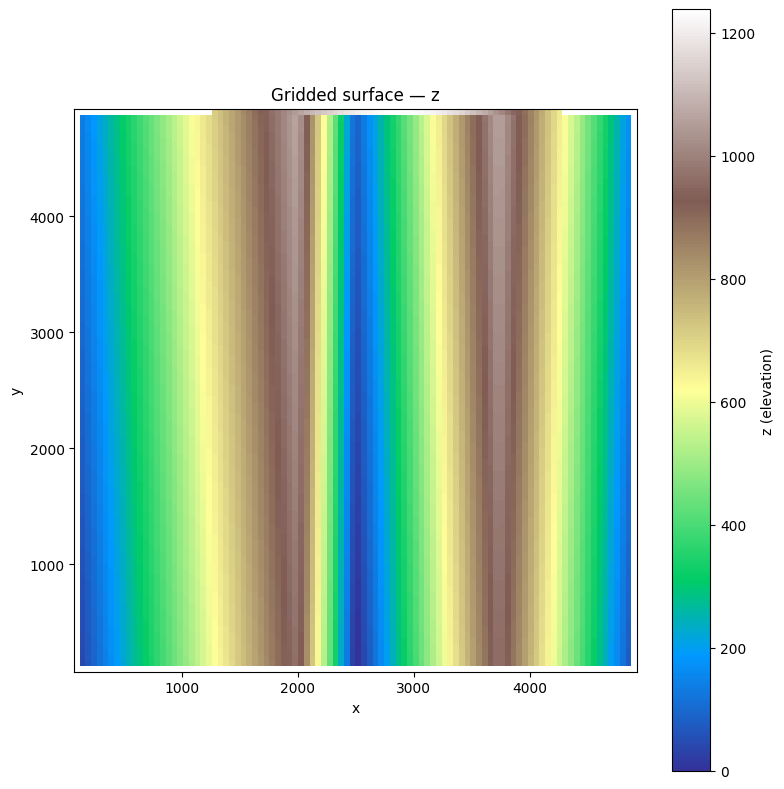

In [15]:
# plot z_grid to check

import matplotlib.pyplot as plt

grid_tag = 'gridplot_'

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(z_grid, cmap='terrain', origin='lower',
               extent=[synscape['x'].min(), synscape['x'].max(), synscape['y'].min(), synscape['y'].max()])
plt.colorbar(im, ax=ax, label='z (elevation)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gridded surface — z')
plt.tight_layout()
# plt.savefig(img_folder + grid_tag + lscape_name_notxt + '.png')
plt.show()

In [7]:
# build separate grid with cohesion only

coh_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['cohesion'].values,
    xi=(xx,yy),
    method='cubic'
)

print(coh_grid.shape)

(98, 98)


In [8]:
# and for tensile strength

ten_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['tension'].values,
    xi=(xx,yy),
    method='cubic'
)

print(ten_grid.shape)

(98, 98)


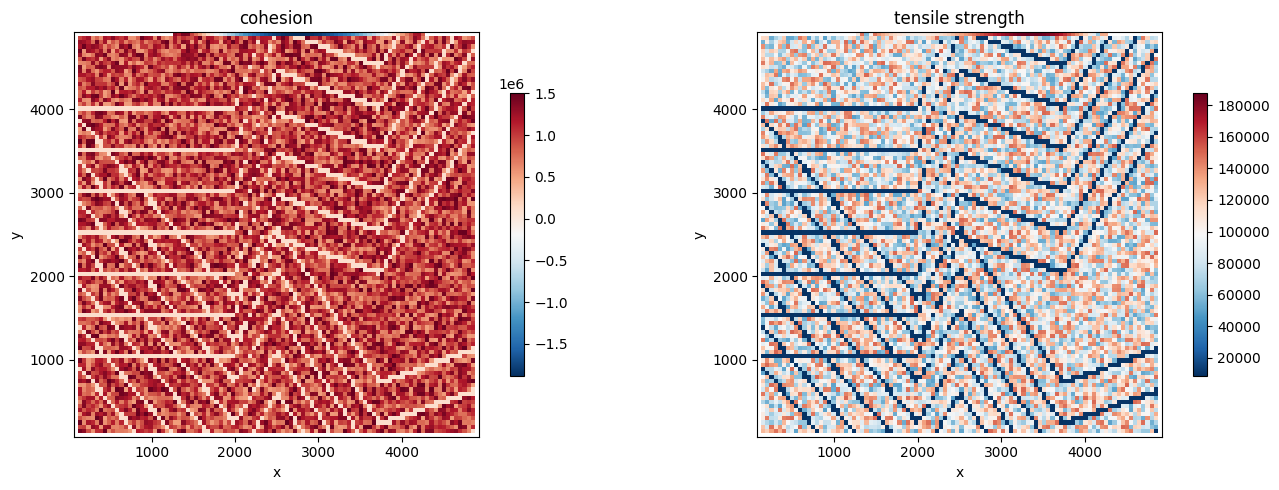

In [16]:
# plot cohesion and tensile strength

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cohten_tag = 'cohten_'

for ax, arr, name in zip(axes,
                         [coh_grid, ten_grid],
                         ['cohesion', 'tensile strength']):
    #print(f"{name}: 2nd pct={vmin:.4f}, 98th pct={vmax:.4f}")
    im = ax.imshow(arr, cmap='RdBu_r', origin='lower',
                   extent=[synscape['x'].min(), synscape['x'].max(),
                                synscape['y'].min(), synscape['y'].max()])
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
#plt.savefig(img_folder + cohten_tag + lscape_name_notxt + '.png')
plt.show()

In [18]:
# begin processing topographic features

In [19]:
from scipy.ndimage import sobel, generic_gradient_magnitude
import numpy as np

# grid resolution
res = (synscape['x'].max() - synscape['x'].min()) / z_grid.shape[0] - 1 # assuming square grid

In [20]:
# first derivatives (gradients)
dz_dy = sobel(z_grid, axis=0) / (8 * res)
dz_dx = sobel(z_grid, axis=1) / (8 * res)

# slope (degrees)
slope = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

print('slope calculated')
print(slope[:5,:5]) # verify contents filling

slope calculated
[[        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan 27.31614586 27.30997295 27.30079441]
 [        nan         nan 27.31347105 27.3075956  27.30115734]
 [        nan         nan 27.31493886 27.30547681 27.29881382]]


In [21]:
# aspect (degrees, 0=north, clockwise)

aspect = np.arctan2(-dz_dx, dz_dy) % 2*np.pi

sinasp = np.sin(aspect)
cosasp = np.cos(aspect)

print("aspect, sinasp, cosasp calculated")
print(sinasp[:5,:5])
print(cosasp[:5,:5])

aspect, sinasp, cosasp calculated
[[       nan        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]
 [       nan        nan 0.995422   0.99537668 0.99537731]
 [       nan        nan 0.99541995 0.99540536 0.99538538]
 [       nan        nan 0.99542539 0.995438   0.99540522]]
[[       nan        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]
 [       nan        nan 0.09557745 0.09604821 0.09604169]
 [       nan        nan 0.09559881 0.09575052 0.09595803]
 [       nan        nan 0.09554214 0.09541068 0.095752  ]]


In [22]:
# curvatures via second derivatives
d2z_dx2 = np.gradient(np.gradient(z_grid, axis=1), axis=1) / res**2
d2z_dy2 = np.gradient(np.gradient(z_grid, axis=0), axis=0) / res**2
d2z_dxdy = np.gradient(np.gradient(z_grid, axis=0), axis=1) / res**2

# profile curvature (in direction of slope)
# k_p = (fxxfx^2 + 2fxyfxfy + fyyfy^2) / ((fx^2 + fy^2)^(3/2))
prof_curv = -((dz_dx**2 * d2z_dx2) + (2*dz_dx*dz_dy*d2z_dxdy) + (dz_dy**2 * d2z_dy2)) / \
                ((dz_dx**2 + dz_dy**2)**1.5 + 1e-10)

plan_curv = (dz_dx**2 * d2z_dy2 - 2*dz_dx*dz_dy*d2z_dxdy + dz_dy**2 * d2z_dx2) / \
                ((dz_dx**2 + dz_dy**2)**1.5 + 1e-10)

print('profile and planar curvatures calculated')

profile and planar curvatures calculated


In [23]:
# sanity check
for name, arr in zip(['slope','aspect','sinasp','cosasp','prof_curv','plan_curv'],
                     [slope, aspect, sinasp, cosasp, prof_curv, plan_curv]):
    print(f"{name}: min={np.nanmin(arr):.5f}, max={np.nanmax(arr):.5f}, mean={np.nanmean(arr):.3f}")

slope: min=2.27879, max=84.94585, mean=36.429
aspect: min=0.00846, max=6.27471, mean=2.665
sinasp: min=-0.99793, max=1.00000, mean=0.295
cosasp: min=-0.99995, max=0.99996, mean=0.125
prof_curv: min=-0.24497, max=0.15070, mean=0.000
plan_curv: min=-0.52417, max=1.08180, mean=0.000


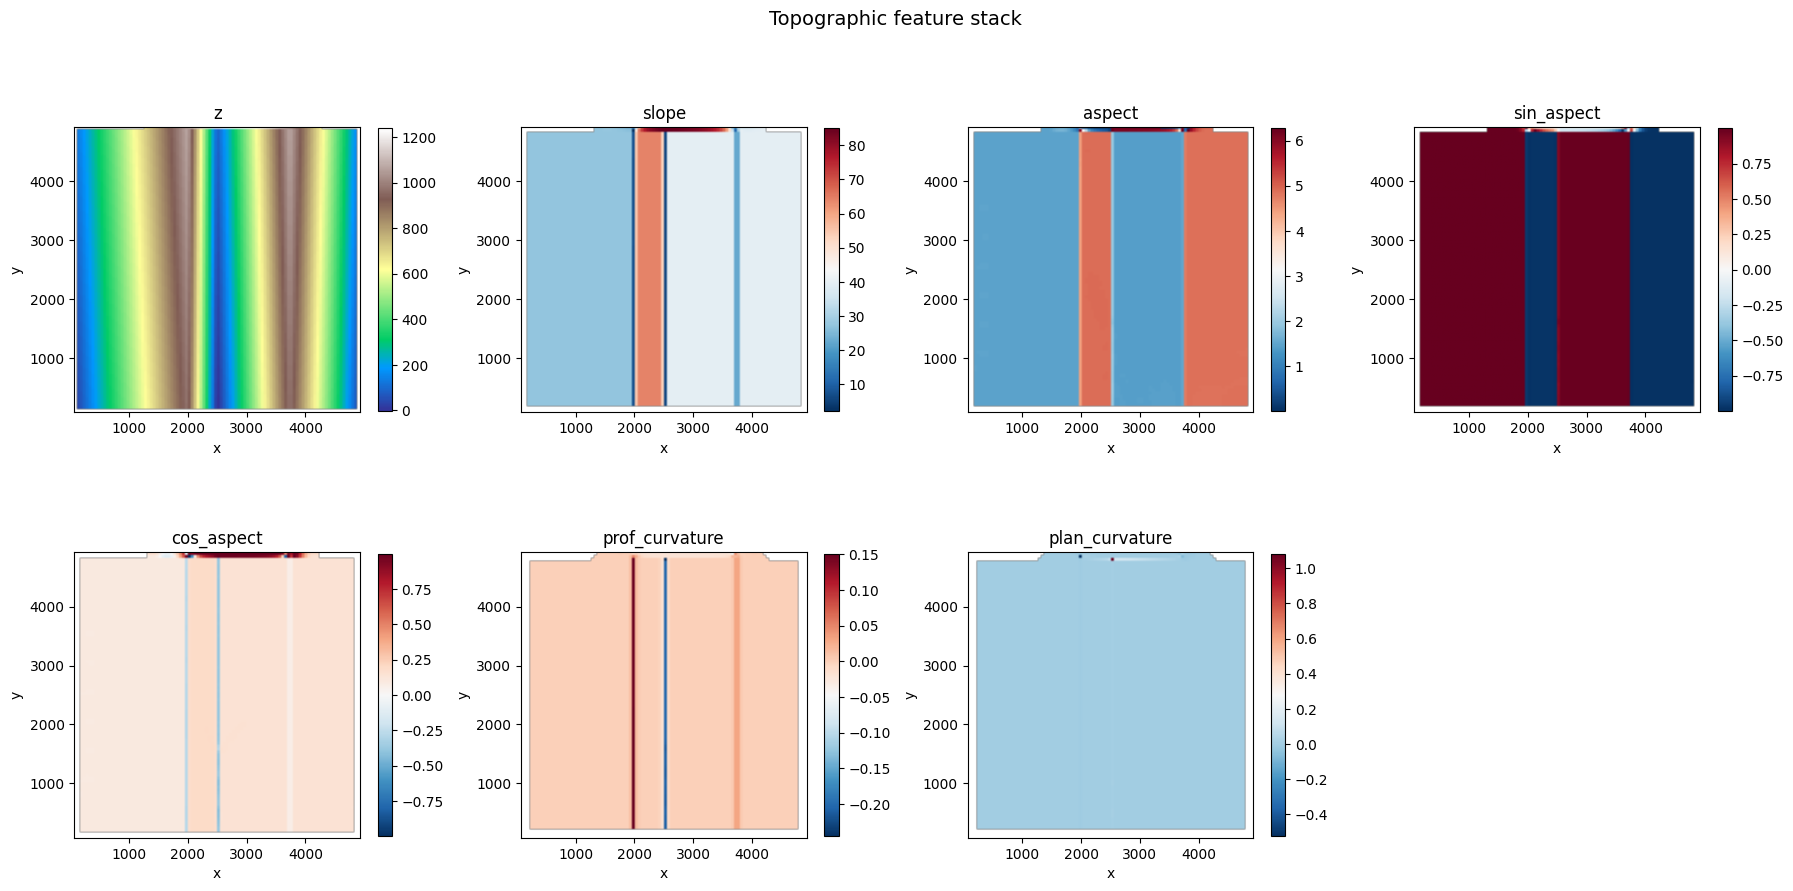

In [25]:
import matplotlib.pyplot as plt

topo_tag = 'topos_'

features = {
    'z': z_grid,
    'slope': slope,
    'aspect': aspect,
    'sin_aspect': sinasp,
    'cos_aspect': cosasp,
    'prof_curvature': prof_curv,
    'plan_curvature': plan_curv
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, (name, arr) in enumerate(features.items()):
    vmin, vmax = np.nanpercentile(arr, [2, 98])
    im = axes[i].imshow(arr, cmap='terrain' if name == 'z' else 'RdBu_r',
                        origin='lower',
                        extent=[synscape['x'].min(), synscape['x'].max(),
                                synscape['y'].min(), synscape['y'].max()])
    plt.colorbar(im, ax=axes[i], shrink=0.7)
    axes[i].set_title(name)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')

# hide the empty 8th panel
axes[-1].set_visible(False)

plt.suptitle('Topographic feature stack', fontsize=14, y=1.01)
plt.tight_layout()
#plt.savefig(img_folder + topo_tag + lscape_name_notxt + '.png')

plt.show()